In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Project Name : Use case 2 Predicting Mental Health


**Author:** Luna Jiang  
**Date:** 30 September 2026  
**Model:** XGBoost Binary Classifier  

---

## Document Contents

The SignOff consists of:

1. Model Aim
2. Target
3. Basefile
4. Features
5. Model and Model evaluation
6. SWOT Analysis
7. Learning and Next steps
8. Questions and Answers Regarding the Task Brief

This document provides an overview of the end-to-end process of the project. The questions from the Task Brief are addressed throughout the different chapters. If you’re short on time, feel free to jump straight to Chapter 9 for a quick overview of the key points.


# 1. Model Aim

The aim of this project is to investigate whether an individual’s demographic, socioeconomic, lifestyle, and health-related characteristics can predict a **reported history of mental illness**.

However a specific usecase has not been defined, the choice of evaluation metric and therefore model and feature selection cannot be finalized. For this project, I assume the usecase is to estimate the **How likely that an individual has a reported history of mental illness**.


# 2. Target

The target variable is:`History_of_Mental_Illness`, a binary value in the dataset.
For modelling, these values are converted to:
- `No` → `0`
- `Yes` → `1`
Therefore, the positive class represents an individual with a **reported history of mental illness**.


| Data Split | No | Yes | Total | Yes Rate (%) |
|---|---:|---:|---:|---:|
| Train | 172,443 | 75,813 | 248,256 | 30.54% |
| Validation | 57,807 | 24,953 | 82,760 | 30.15% |
| Test | 57,693 | 25,059 | 82,752 | 30.28% |

The target is consistently distributed across the train, validation, and test sets, with the **positive class at around ~30%** in each split. This is not a severe class imbalance.

In healthcare data, its comment that features/data have **low prevalence or high cardinality**, so imbalance should be considered at both the target and feature levels.

Possible approaches in this case include:
1. Oversample the positive class.
2. Undersample the negative class.
3. Apply class weights / `scale_pos_weight`.
4. Keep the original distribution and tune the classification threshold based on the stakeholder’s usecase, especially if the output is used for risk ranking or prioritisation.

Given the current ~30% positive rate, and keeping the original basefile is important, and regading the model aim relative to proritisation, I'll use method 4.

# 3. Basefile

The dataset used in this project is the Kaggle Depression Dataset: https://www.kaggle.com/datasets/anthonytherrien/depression-dataset/data

The Basefile contains 414,000 records. There are no duplicate records or rows with missing values.

After checking the unique values, I found that even the combination of Name and Age could not uniquely identify each record. Therefore, I added a `record_ID` using `range(100000, 100000 + len(df))`, resulting in IDs from **100,000 to 513,999**.

I split the data into **Train, Validation, and Test sets** with a **60:20:20** proportion based on `record_ID`. Train set: Used for data exploration, model selection, and hyperparameter tuning. Validation set: Used to compare candidate models and select the final model. Test set: Kept completely unseen throughout the training and model selection process, and used only at the end to provide an unbiased estimate of the final model’s performance.

`train if x % 60 < 36`

`validation if x % 60 < 48`

`else test`

# 4. Features

## Feature List
| Feature | Type | Finding | Transformation | Encoder |
|---|---|---|---|---|
| **Age** | Numerical | Relatively balanced across the positive and negative classes, with no significant skew. | Keep as original value. | |
| **Income** | Numerical | Right-skewed and shows a strong relationship with the target, making it a potentially strong predictor. | Keep original value for explainability; cap at **150,000** to reduce the impact of extreme values. | |
| **Number of Children** | Categorical / Ordinal | Although stored as an integer, the values represent discrete customer choices. Value **4** has very low exposure. | Group **4+** into **3+**. | Ordinal Encoder |
| **Employment Status** | Binary | Two categories with a direct binary interpretation. | `Employed = 1`, `Unemployed = 0`. | Manual Binary Mapping|
| **History of Substance Abuse** | Binary | Two categories with a direct binary interpretation. | `Yes = 1`, `No = 0`. | Manual Binary Mapping|
| **Family History of Depression** | Binary | Two categories with a direct binary interpretation. | `Yes = 1`, `No = 0`. | Manual Binary Mapping|
| **Chronic Medical Conditions** | Binary | Two categories with a direct binary interpretation. | `Yes = 1`, `No = 0`. | Manual Binary Mapping|
| **Education Level** | Categorical | `PhD` has relatively low exposure (~4%), but merging it with `Master's` could remove useful information. | Keep as categorical. | Ordinal Encoder |
| **Smoking Status** | Categorical | Positive rates are relatively consistent across categories, with no clear target trend. | Keep as categorical. | Ordinal Encoder |
| **Physical Activity Level** | Categorical | Positive rates are relatively consistent across categories, with no clear target trend. | Keep as categorical. | Ordinal Encoder |
| **Alcohol Consumption** | Categorical | Positive rates are relatively consistent across categories, with no clear target trend. | Keep as categorical. |Ordinal Encoder  |
| **Dietary Habits** | Categorical | `Healthy` shows a slightly higher positive rate than other categories. | Keep as categorical. |Ordinal Encoder  |
| **Sleep Patterns** | Categorical | `Fair` and `Good` show slightly higher positive rates. | Keep as categorical. | Ordinal Encoder |
| **Marital Status** | Categorical | `Widowed` and `Divorced` may have different relationships with the target, so combining them could remove useful signal. | Keep as categorical. |Frequent Encoder  |
| | | | | |

## Feature Importance

After frist round of dauflt XGBoost model, the feature Importance is:

|    | **Feature**                           |   **Gain** | **SHAP** | **Permutation** | **Gain_Rank** | **SHAP_Rank** | **Permutation_Rank** | **Overall_Rank** |
| -: | ------------------------------------- | ---------: | -------: | --------------: | ------------: | ------------: | -------------------: | ---------------: |
|  8 | numeric__Income                       | 149.581253 | 0.096367 |        0.091615 |           1.0 |           1.0 |                  1.0 |         1.000000 |
|  0 | ordinal__Education_Level              |  59.977940 | 0.018247 |        0.021949 |           3.0 |           2.0 |                  2.0 |         2.333333 |
|  6 | ordinal__Smoking_Status               |  81.867981 | 0.011438 |        0.011998 |           2.0 |           3.0 |                  3.0 |         2.666667 |
|  7 | numeric__Age                          |   3.524517 | 0.002615 |        0.000151 |           7.0 |           4.0 |                  6.0 |         5.666667 |
|  9 | numeric__Marital_Status               |   3.485536 | 0.000971 |        0.000222 |           8.0 |           6.0 |                  4.0 |         6.000000 |
|  3 | ordinal__Alcohol_Consumption          |   4.223040 | 0.000206 |        0.000182 |           4.0 |          10.0 |                  5.0 |         6.333333 |
|  2 | ordinal__Sleep_Patterns               |   3.616696 | 0.001531 |       -0.000040 |           6.0 |           5.0 |                 13.0 |         8.000000 |
|  5 | ordinal__Number_of_Children           |   2.617449 | 0.000649 |        0.000127 |          11.0 |           7.0 |                  7.0 |         8.333333 |
| 12 | numeric__Family_History_of_Depression |   3.777727 | 0.000168 |       -0.000004 |           5.0 |          11.0 |                 11.0 |         9.000000 |
|  1 | ordinal__Physical_Activity_Level      |   2.846459 | 0.000444 |        0.000091 |          10.0 |           9.0 |                  8.0 |         9.000000 |
|  4 | ordinal__Dietary_Habits               |   3.266764 | 0.000130 |       -0.000039 |           9.0 |          12.0 |                 12.0 |        11.000000 |
| 13 | numeric__Chronic_Medical_Conditions   |   2.529554 | 0.000558 |       -0.000086 |          12.0 |           8.0 |                 14.0 |        11.333333 |
| 11 | numeric__History_of_Substance_Abuse   |   2.242326 | 0.000000 |        0.000000 |          13.0 |          13.5 |                  9.5 |        12.000000 |
| 10 | numeric__Employment_Status            |   0.000000 | 0.000000 |        0.000000 |          14.0 |          13.5 |                  9.5 |        12.333333 |




I initially added `reg_alpha` (L1 regularisation) into the simple XGBoost model as an initial feature-screening step. The purpose was to buid a simple model and obtain a first idea of which variables contributed to the model. 

I then compared feature improtance like Gain, SHAP and PI values to check removing lower-contributing variables.

Based on the initial feature importance results, and given the short project timeframe, I decided to remove the bottom seven features from the initial feature list and continue modelling with the reduced feature list.

## Reduced Feature List

- Education_Level
- Smoking_Status
- Alcohol_Consumption
- Dietary_Habits
- Physical_Activity_Level
- Number_of_Children
- Age
- Income
- Marital_Status

# 5. Model

The Task Brief does not specify which model should be used, so I would normally compare several models, such as Logistic Regression, GLM, XGBoost, and EBM.

However, for this project, I want to focus on how I would take an initial stakeholder idea and turn it into an end-to-end data science workflow as a healthcare data scientist.

Therefore I started with a simple XGBoost classification model. Based on my practical experience, XGBoost often provides strong predictive performance compared with simpler models such as Logistic Regression, GLM, and EBM. It also provides useful tools for model interpretation, which is important in this usecase.


# 6. SWOT Analysis

## Strengths

- The model achieves around 37% positive rate in the highest-risk band, compared with an overall target rate of around 30%.
- Multiple evaluation metrics were used to assess model performance.
- Separate training, validation, and test sets were used to reduce the risk of overfitting and data leakage.

## Weaknesses

- The target represents a reported history of depression, not necessarily the individual’s current mental health status. This may limit how well the model reflects the current situation.
- The model has not been fully hyperparameter-tuned.
- The model results is not significant.
- Feature relationships were mainly explored through EDA and model-based methods; correlation analysis was not formally included.

## Opportunities

- Adding more relevant features could improve predictive performance.
- Further feature engineering could improve the model.
- Compare the current model with Logistic Regression and Random Forest as baseline models.
- Apply probability calibration to make predicted probabilities more reliable.

## Threats

- The synthetic dataset may not fully represent real-world populations  healthcare settings.
- Some features may act as proxies for sensitive characteristics, so their use should be carefully considered in a healthcare context.
- There is a risk that model predictions could be misinterpreted as clinical diagnoses, even though the model only predicts the likelihood of a reported history of mental illness.


# 7. Learning and Next Steps

## Key Learning

One of the main lessons from this project was that increasing model complexity does not always improve predictive performance. As a data scientist, we need to find the right balance between model performance, complexity and the time available. It is also important to explain the possible consequences of each decision to stakeholders, discuss alternative solutions, and keep the business usecase as the main goal.

Because my personal laptop took longer to run hyperparameter tuning, I also learned how to manually tune model parameters. This helped me understand how different parameters can affect the model and how to identify signs of overfitting and underfitting.

Although the predicted probabilities were not perfectly calibrated with the actual outcomes, but I managed to tune the model and achieve validation and test AUROC scores of around 0.60 after few initrative.

Given the limited project timeframe and computing resources, I was satisfied with using a practical manual tuning approach and focusing on a solution that could be completed within the required timeframe.

## Next Steps

If more time and resources were available, I would try:

1. Try use this XGBoost model as baseline and compare with few more different ML approaches.
2. Investigate additional feature engineering, and adding more features.
3. Compare feature sets in more variorty way such as: correlation and feature interaction.
4. Fine tuning the model.
5. Perform a more detailed subgroup analysis.
6. Validate the model using an independent dataset.
7. Investigate additional clinically relevant variables.

# 8. Questions and Answers Regarding the Task Brief


## Question 1:
Use methods of your choice (e.g. exploratory data analysis, statistical methods, visualisations etc.)
to extract useful insights from the data.

In `data_explore.ipynb`, I started with a few simple data checks.

### Unique Key Check

I first checked whether the dataset contained a column, or combination of columns, that could uniquely identify each record. No suitable unique key was found.

Therefore, I created a new `record_ID` using:

```python
range(100000, 100000 + len(df))
```

For this dataset, this resulted in `record_ID` values from **100,000 to 513,999**.

### Train, Validation, and Test Split

I then split the data into **Train, Validation, and Test sets** using a **60:20:20** proportion.

The split was based on `record_ID` using the following logic:

```python
if x % 60 < 36:
    train
elif x % 60 < 48:
    validation
else:
    test
```

In [2]:
df = pd.read_csv("../data/mental_health_data.csv")
summary_df = (
    df.groupby("data_split")["History_of_Mental_Illness"]
    .value_counts()
    .unstack(fill_value=0)
)

summary_df["Total"] = summary_df.sum(axis=1)
summary_df["Yes Rate (%)"] = (
    summary_df["Yes"] / summary_df["Total"] * 100
).round(2)

summary_df

History_of_Mental_Illness,No,Yes,Total,Yes Rate (%)
data_split,,,,
test,57693,25059,82752,30.28
train,172443,75813,248256,30.54
validation,57807,24953,82760,30.15


The positive class was around 30% in all three datasets.

### Missing Value

There is no missing value.

### Duplicated Rows

There are no duplicate rows.

### EDA

The EDA found that the dataset is generally clean and well structured, with no duplicate rows or missing values. The target variable, `History of Mental Illness`, has a positive rate of approximately 30%, indicating a slightly imbalance rather than a severe imbalance. Among the numerical variables, `Age` is relatively evenly distributed, while `Number of Children` and particularly `Income` show right-skewed distributions. 

Most features have a relatively balanced distribution across their categories, with sufficient exposure in the all groups. However, a few features required additional consideration during preprocessing. `Marital Status` has slightly low exposure in the `Widowed` category, but it has a high positive rate. I considered grouping `Widowed` and `Divorced` into one group due to the small exposure. However, in a healthcare usecase, treating vulnerable customers fairly depends on the specific usecase. As we have not yet determined how the prediction will be used, I decided to keep them separate to avoid potentially removing useful information.

Similarly, `Education Level` had relatively low exposure in the `PhD` category (approximately 4%), but this group was retained as its own category because combining it with `Master's` could remove potentially useful information.

`Number of Children` was treated as a discrete categorical/ordinal feature rather than a continuous numerical variable. As the value `4` had very low exposure, values of `4` were grouped into the `3` category to reduce the impact of a low frequency group.

From the EDA plots, `Income` showed a strong relationship with positive cases in the box plot. This was also supported by the model, which identified `Income` as the most important feature for predicting a history of mental illness.

Overall, the EDA showed the features' categorisations and properties. Based on this, I applied some transformations, preprocessing and encoding, which can be found in Chapter 5. However, the analysis could be strengthened by examining feature correlations and interactions, and evaluating them with statical methods. These steps would provide stronger evidence for the preprocessing decisions and help determine whether the patterns observed during EDA are robust.

## Question 2:
Use suitable model to predict whether an individual will suffer mental illness (variable titled “History of Mental Illness”) using all or some of the other variables present in the data.

Your answer should also contain:
1. Narratives for including/excluding variables of choice;
2. Narrative supporting the model/s of choice,
3. An assessment of model performance,
4. Assessment of potential model biases.

### Objectives

The objective of this project was to investigate whether an indiviual have `History_of_Mental_Illness` or not. However, an important limitation is that the target is a reported history of mental illness, rather than whether an individual will have a mental illness with current situation, which mean we are using a current situation to predict a history of depression. 

### Feature Selection

I removed `Name` in my dataset, because its irrelevent to prediction and might intoduce biases.

I then started with all 14 available features and used EDA and a simple XGBoost model to assess all features. The EDA showed that most features had enough exposure across their categories. However, some categories had low exposure and needed extra consideration, after some feature processing, `Income` showed the clearest difference between positive and negative cases in the EDA. This was also supported by the first XGBoost model, where `Income` had the highest Gain, SHAP, and permutation importance. `Education_Level` and `Smoking_Status` also showed relatively higher feature importance compared with the other variables.

I compared Gain, SHAP, and permutation importance rather than relying on a single feature importance. Based on these results, I removed the lower-contributing features and continued modelling with a reduced feature set containing:
* `Education_Level`
* `Smoking_Status`
* `Alcohol_Consumption`
* `Dietary_Habits`
* `Physical_Activity_Level`
* `Number_of_Children`
* `Age`
* `Income`
* `Marital_Status`

This feature reduction decision is broad. A feature with low importance may still be useful through feature interactions. Also, correlated features can affect feature importance, which has not been investigated. However, when delivering quick results or handling large datasets or feature sets, this method helps us remove features quickly and therefore obtain quick but efficient results.

### Model Selection

The Task Brief did not specify a model. Normally, I would compare several models, such as Logistic Regression, GLM, EBM, Random Forest, and XGBoost. For this project, I selected **XGBoost Classifier** as the initial model. XGBoost can capture non-linear relationships and feature interactions with powerful results, and XGBoost can handle imbalanced datasets effectivily. I started with a simple XGBoost model and then manually tuned some model parameters. I also used regularisation to help control model complexity.

However, I would not say that XGBoost is definitely the best model for this healthcare use case. The specific usecase has not yet been defined. Therefore, the final model should only be selected after understanding what decision the model will support.

### Model performance

The positive rate of the target is around 30% across the train, validation, and test sets. This shows that the target distribution is consistent across the three datasets.

I kept the original class distribution rather than using oversampling or undersampling. Given the current positive rate and also assumed usecase need prioritisation. After initial modelling and few manual tunings, the model achieved validation and test AUROC scores of around 0.60.

This shows that the model has some ability to separate positive and negative cases, but the predictive performance is limited. The predicted probabilities were also not perfectly calibrated.

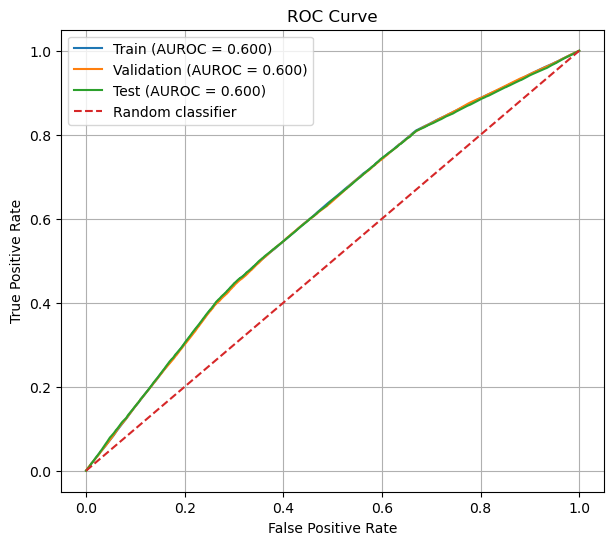

The highest-risk group had a positive rate of around 37%, compared with around 30% in the full dataset. This shows some separation between the higher-risk group and the overall population. However, the difference is not large enough to claim strong clinical value without a clear use case and decision threshold.

| **pred_group** | **XGBoost_9features_actual** | **XGBoost_9features_predict** |
|---------------:|-----------------------------:|-------------------------------:|
| 0              | 0.193183                     | 0.229004                       |
| 1              | 0.201045                     | 0.234587                       |
| 2              | 0.218423                     | 0.246898                       |
| 3              | 0.293287                     | 0.288418                       |
| 4              | 0.299039                     | 0.305430                       |
| 5              | 0.299766                     | 0.309726                       |
| 6              | 0.329469                     | 0.336646                       |
| 7              | 0.395335                     | 0.356686                       |
| 8              | 0.391210                     | 0.368580                       |
| 9              | 0.397830                     | 0.377507                       |

### Potential model bias
First, the target is based on a **reported history of mental illness**. It may not represent a person's actual mental health status. For example, differences in healthcare access, willingness to report mental health problems, or recording practices may affect the target. The model may therefore learn patterns related to reporting or healthcare access rather than mental illness itself.

Second, some features may act as **proxies** for sensitive or socioeconomic characteristics. For example, `Income`, `Education_Level`, and `Marital_Status` may reflect wider socioeconomic or demographic differences. A feature being predictive does not automatically mean it should be used in a healthcare decision.

Third, XGBoost has strong predictive power, but it can lack interpretability and explainability. This could be a problem for some use cases and make the model harder to explain to stakeholders. However, I have used **SHAP, ALE, and PDP plots** for key features, which can help improve the model's explainability.

Finally, there may be other important factors that influence a reported history of mental illness but are not included in the dataset. The current results also suggest that financial factors may be an important indicator. Therefore, adding more affluence features, if available and ethical allowed, could be useful for further investigation.

## Question 3:
What are the limitations of your chosen approach? How might you improve the performance of your model?

XGBoost is a relatively complex model, so its predictions are less directly interpretable than those of a simple Logistic Regression model. However, using SHAP, ALE, and PDP plots can help stakeholders better understand how key features contribute to the model's predictions and how changes in these features are related to the predicted outcome.

The model also has limited predictive performance, with an AUROC of around 0.60 after the current tuning process. This suggests that the available features provide some useful information, but their predictive power is limited. The model was manually tuned based on my understanding of how different parameters can help manage overfitting and underfitting. There is also a trade off between model complexity, predictive performance, and interpretability. Therefore, it is important to discuss these trade offs with stakeholders and agree on the project goal before deciding a final model.

Finally, the available features are limited and may not fully represent the factors that influence mental health in a real-world healthcare population. Therefore, the model's performance and fairness may not generalise to other populations or healthcare settings. Further feature engineering could create more meaningful or aggregated features. In particular, `Income` was identified as the most important feature in the current model, so adding other relevant socioeconomic or affluence-related features, where appropriate, could be useful for further investigation. However, these features should also be assessed carefully because they may act as proxies for broader socioeconomic differences.
